# Drone Sensor Health Monitoring with a Feed-Forward Neural Network

Modern autonomous systems continuously collect telemetry from sensors.

A drone may monitor:

- battery state,
- motor temperature,
- vibration,
- altitude,
- environmental conditions.

The goal of this experiment is to build a small neural network that learns to
estimate system health from sensor measurements.

This notebook demonstrates the complete `nnlab` workflow:

sensor measurements
    ↓
feature transformation
    ↓
neural network
    ↓
health prediction
    ↓
evaluation

The data used in this experiment is synthetic telemetry generated to represent
normal and degraded flight conditions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from nnlab.kernels import LogisticKernel

from nnlab.activations import ParameterizedActivation

from nnlab.layers import (
    Dense,
    ActivationLayer,
)

from nnlab.models import FeedForward

from nnlab.losses import MeanSquaredError

from nnlab.optimizers import SGD

from nnlab.training import Trainer

## Simulated Drone Telemetry

A real drone would stream sensor data from onboard hardware.

For this experiment we generate simplified telemetry:

Features:

- battery voltage
- motor temperature
- vibration level
- altitude variation
- current draw

The network will learn the relationship between sensor state and overall
vehicle health.

In [2]:
samples = 2000

rng = np.random.default_rng( seed=42, )
battery = rng.normal( 15.0, 0.5, samples, )
temperature = rng.normal( 50.0, 8.0, samples, )
vibration = rng.normal( 0.2, 0.05, samples, )
altitude_variation = rng.normal( 0.0, 0.5, samples, )
current_draw = rng.normal( 8.0, 1.0, samples, )

In [3]:
faults = rng.random(samples) < 0.25

temperature[faults] += rng.normal( 30, 5, faults.sum(), )
vibration[faults] += rng.normal( 0.5, 0.1, faults.sum(), )
battery[faults] -= rng.normal( 1.5, 0.3, faults.sum(), )
current_draw[faults] += rng.normal( 3, 1, faults.sum(), )

In [4]:
x = np.column_stack(
    [ battery, temperature, vibration, altitude_variation, current_draw, ]
)

In [7]:
health = np.ones( samples, )
health[faults] = 0.0
y = health.reshape( -1, 1, )

## Sensor Scaling

Sensors operate on different scales.

Battery voltage, temperature, and vibration cannot be passed directly into a
network without adjustment.

The values are normalized so each feature contributes on a comparable scale.

In [8]:
x_mean = x.mean( axis=0, )
x_std = x.std( axis=0, )
x = ( x - x_mean ) / x_std

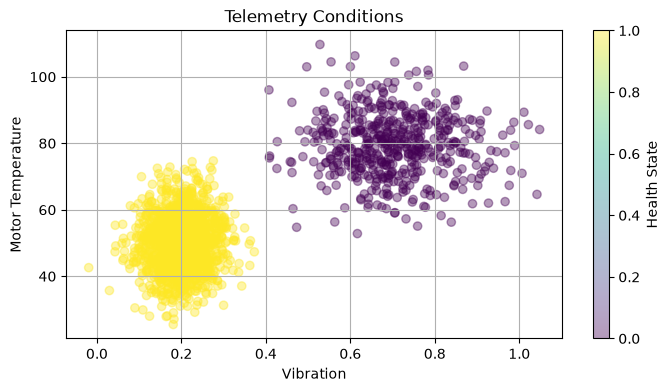

In [15]:
plt.figure(figsize=(8,4))

plt.scatter( vibration, temperature, c=health, alpha=0.4, )
plt.xlabel( "Vibration", )
plt.ylabel( "Motor Temperature", )
plt.title( "Telemetry Conditions", )
plt.grid()

plt.colorbar(
    label="Health State",
)

plt.show()

## Health Prediction Network

The network receives five sensor measurements and predicts a continuous health
score.

The output represents:

1.0 → healthy system

0.0 → degraded system

In [10]:
model = FeedForward(
    layers=[
        Dense(
            input_size=5,
            output_size=16,
        ),

        ActivationLayer(
            ParameterizedActivation(
                kernel=LogisticKernel(),
            )
        ),

        Dense(
            input_size=16,
            output_size=8,
        ),

        ActivationLayer(
            ParameterizedActivation(
                kernel=LogisticKernel(),
            )
        ),

        Dense(
            input_size=8,
            output_size=1,
        ),
    ],
)

In [11]:
trainer = Trainer(
    model=model,
    loss=MeanSquaredError(),
    optimizer=SGD(
        learning_rate=0.01,
    ),
)


history = trainer.fit(
    x,
    y,
    epochs=500,
)

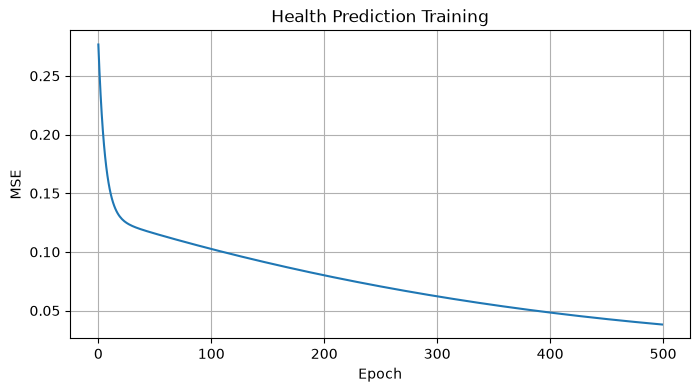

In [12]:
plt.figure(figsize=(8,4))

plt.plot(
    history,
)

plt.title(
    "Health Prediction Training",
)

plt.xlabel(
    "Epoch",
)

plt.ylabel(
    "MSE",
)

plt.grid()

plt.show()

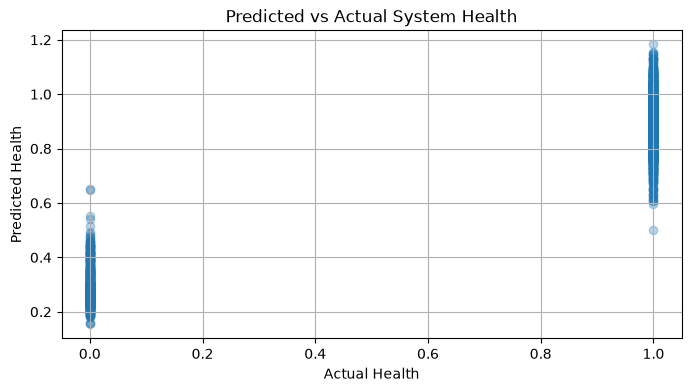

In [13]:
prediction = trainer.predict(
    x,
)

plt.figure(figsize=(8,4))

plt.scatter(
    y,
    prediction,
    alpha=0.3,
)

plt.xlabel(
    "Actual Health",
)

plt.ylabel(
    "Predicted Health",
)

plt.title(
    "Predicted vs Actual System Health",
)

plt.grid()

plt.show()

In [14]:
example = np.array(
    [
        x[0],
        x[-1],
    ]
)

trainer.predict(
    example,
)

array([[0.98266864],
       [0.29868784]])

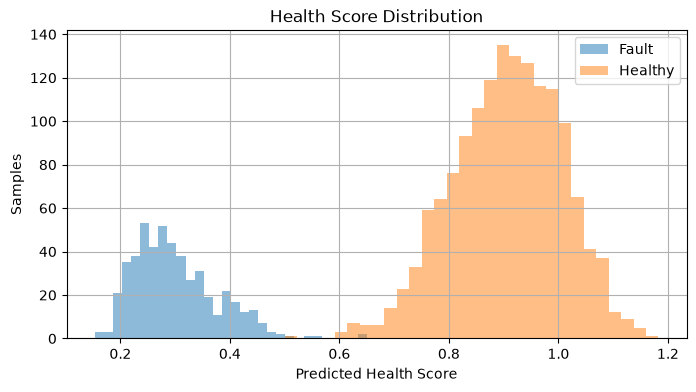

In [16]:
plt.figure(figsize=(8,4))

plt.hist(
    prediction[y.flatten() == 0],
    bins=30,
    alpha=0.5,
    label="Fault",
)

plt.hist(
    prediction[y.flatten() == 1],
    bins=30,
    alpha=0.5,
    label="Healthy",
)

plt.xlabel(
    "Predicted Health Score",
)

plt.ylabel(
    "Samples",
)

plt.title(
    "Health Score Distribution",
)

plt.legend()
plt.grid()

plt.show()

## Observations

This experiment demonstrates how the same neural network concepts used for
mathematical function approximation can be applied to a practical sensing
problem.

The model learned relationships between multiple sensor measurements and a
system health estimate.

Important engineering considerations include:

- sensor normalization,
- noisy measurements,
- model capacity,
- optimization stability.

Real autonomous systems extend this idea with additional techniques such as:

- time-series models,
- uncertainty estimation,
- fault classification,
- online learning.

The fundamental workflow remains the same:

measure → represent → learn → predict.